# 06 — V-JEPA 2.1-B + CCD on-the-fly synthetic re-recording

**목표**: Public Stage1 `0.9549731183`을 만든 A7 V-JEPA 2.1-B를 anchor로 유지하면서, CCD driving video에 **저장하지 않는(on-the-fly) screen-recapture simulation**을 적용해 target-like domain adaptation을 시도한다.

핵심 원칙:

- A7의 **1-clip / 16 frames / 384px / threshold 0.5** 설정은 유지한다.
- V-JEPA backbone은 첫 06 실험에서 **head-only**로 고정한다.
- A7 `best.pt`에서 warm-start한다. 처음부터 새 head를 학습하지 않는다.
- CCD source 하나를 `ORIGINAL`과 `SYN-RR`로 쌍(pair)으로 사용한다. 영상 파일은 복제하지 않는다.
- blur/noise/resize 같은 일반 nuisance는 CCD 양쪽 class에 공통으로 일부 적용한다.
- moiré / scan banding / display colour response / screen-camera resampling은 SYN-RR에만 적용한다.
- train synthetic은 매 접근마다 랜덤, validation synthetic은 video id 기반 deterministic seed를 사용한다.
- checkpoint 선택 validation은 DLC val + **별도 CCD-val source의 medium SYN-RR pair**를 함께 사용한다.
- 마지막에 DLC val 성능이 A7보다 떨어지면 후보를 채택하지 않는다.

> 이 notebook은 synthetic 영상을 Drive에 저장하지 않는다. 원본 CCD만 읽고 16-frame tensor에 실시간 변형을 적용한다.


## 1. Colab / repository setup


In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
import time
from pathlib import Path

import warnings

warnings.filterwarnings(
    "ignore",
    message=r".*torch\.backends\.cuda\.sdp_kernel.*deprecated.*",
    category=FutureWarning,
)

REPO_URL = "https://github.com/sangchun1/Blackbox-Detection.git"
BRANCH = "stage1-sangchun"

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount("/content/drive", force_remount=False)
except ModuleNotFoundError:
    print("Not running in Google Colab; Drive mount skipped.")

if IN_COLAB:
    REPO_ROOT = Path("/content/Blackbox-Detection")
    if not (REPO_ROOT / ".git").is_dir():
        subprocess.run(
            [
                "git", "clone", "--depth", "1", "--branch", BRANCH,
                "--single-branch", REPO_URL, str(REPO_ROOT),
            ],
            check=True,
        )
    else:
        current_branch = subprocess.run(
            ["git", "-C", str(REPO_ROOT), "branch", "--show-current"],
            check=True, capture_output=True, text=True,
        ).stdout.strip()
        if current_branch != BRANCH:
            subprocess.run(["git", "-C", str(REPO_ROOT), "checkout", BRANCH], check=True)

        dirty = subprocess.run(
            ["git", "-C", str(REPO_ROOT), "status", "--porcelain"],
            check=True, capture_output=True, text=True,
        ).stdout.strip()
        if dirty:
            print("WARNING: local repo has changes; git pull skipped.")
        else:
            subprocess.run(
                ["git", "-C", str(REPO_ROOT), "pull", "--ff-only", "origin", BRANCH],
                check=True,
            )
else:
    REPO_ROOT = Path.cwd().resolve()
    while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "pyproject.toml").is_file():
        REPO_ROOT = REPO_ROOT.parent
    if not (REPO_ROOT / "pyproject.toml").is_file():
        raise FileNotFoundError("Run this notebook inside Blackbox-Detection repository.")

os.chdir(REPO_ROOT)

# Keep Colab's binary scientific stack. Do not let editable install replace NumPy/SciPy/PyTorch.
COLAB_EXTRAS = [
    "av>=15,<17",
    "timm==1.0.15",
    "fvcore==0.1.5.post20221221",
    "iopath==0.1.10",
    "yacs==0.1.8",
    "einops==0.8.1",
    "transformers==4.57.6",
    "accelerate==1.9.0",
    "huggingface-hub==0.34.4",
    "safetensors==0.6.2",
    "sentencepiece==0.2.0",
    "tokenizers>=0.22,<0.24",
    "omegaconf==2.3.0",
    "hydra-core==1.3.2",
    "wandb==0.29.0",
    "easydict==1.13",
]
if IN_COLAB:
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            "--upgrade-strategy", "only-if-needed", *COLAB_EXTRAS,
        ],
        check=True,
    )

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e", str(REPO_ROOT)],
    check=True,
)
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
import torch
import yaml

from blackbox_detection.utils import (
    finish_wandb,
    init_wandb,
    load_checkpoint,
    seed_everything,
    setup_logger,
)
from blackbox_detection.stage1.dataset import Stage1VideoDataset, build_dataloader, video_batch_adapter
from blackbox_detection.stage1.evaluator import AggregationConfig, Stage1Evaluator, save_predictions
from blackbox_detection.stage1.models import build_stage1_model, count_parameters
from blackbox_detection.stage1.recapture import (
    OnTheFlyRecaptureDataset,
    RecaptureMode,
    RecaptureSimConfig,
    RecaptureSimV1,
)
from blackbox_detection.stage1.sampling import build_clip_sampler
from blackbox_detection.stage1.trainer import Stage1Trainer, TrainConfig
from blackbox_detection.stage1.transforms import ClipAugmentConfig, build_video_transforms

logger = setup_logger("stage1.vjepa2_ccd_synrr")

DRIVE_PROJECT_ROOT = Path("/content/drive/MyDrive/Blackbox-Detection")
DATASET_ROOT = DRIVE_PROJECT_ROOT / "DATASET"
DLC_ROOT = DATASET_ROOT / "DLC-2021"
CCD_ROOT = DATASET_ROOT / "CCD"
DLC_SPLIT_CSV = DLC_ROOT / "dlc_split.csv"
CCD_SPLIT_CSV = CCD_ROOT / "ccd_split.csv"
OUTPUT_ROOT = DRIVE_PROJECT_ROOT / "outputs" / "stage1"
WANDB_KEY_PATH = DRIVE_PROJECT_ROOT / "wandb_key.txt"
CONFIG_DIR = REPO_ROOT / "configs" / "stage1"

GIT_COMMIT = subprocess.run(
    ["git", "-C", str(REPO_ROOT), "rev-parse", "--short", "HEAD"],
    check=True, capture_output=True, text=True,
).stdout.strip()

print("repo   :", REPO_ROOT)
print("commit :", GIT_COMMIT)
print("torch  :", torch.__version__)
print("cuda   :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu    :", torch.cuda.get_device_name(0))


Mounted at /content/drive
repo   : /content/Blackbox-Detection
commit : 27cc1fb
torch  : 2.8.0+cu126
cuda   : True
gpu    : NVIDIA A100-SXM4-80GB


## 2. Experiment knobs


In [2]:
# Conservative first CCD synthetic experiment.
MODEL_NAME = "vjepa2_1_b"
A7_VARIANT = "dlc"
A7_RUN_DIR = OUTPUT_ROOT / A7_VARIANT / MODEL_NAME
A7_BEST = A7_RUN_DIR / "best.pt"
A7_PUBLIC_ANCHOR = 0.9549731183

# Number of *CCD source videos*; each train source becomes an ORIGINAL + SYN-RR pair.
CCD_TRAIN_SOURCES = 200
CCD_VAL_SOURCES = 60
CCD_SAMPLE_SEED = 42

# Warm-start adaptation. Keep the pretrained V-JEPA representation protected.
FORCE_HEAD_ONLY = True
EPOCHS_OVERRIDE = 10
LR_SCALE_FROM_A7 = 0.25
EARLY_STOPPING_PATIENCE = 3

# Checkpoint selection sees DLC val + deterministic medium synthetic CCD-val pairs.
SELECTION_SYN_STRENGTH = "medium"
DIAGNOSTIC_STRENGTHS = ("weak", "medium", "strong")

# Diagnostics before training are useful because they reveal whether the simulator is already too easy.
RUN_A7_BASELINE_DIAGNOSTICS = True

RUN_VARIANT = f"dlc_ccd_synrr_{CCD_TRAIN_SOURCES}"
RUN_DIR = OUTPUT_ROOT / RUN_VARIANT / MODEL_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

if not A7_BEST.is_file():
    raise FileNotFoundError(f"A7 checkpoint not found: {A7_BEST}")

print("A7 checkpoint :", A7_BEST)
print("06 output     :", RUN_DIR)
print("CCD train src :", CCD_TRAIN_SOURCES)
print("CCD val src   :", CCD_VAL_SOURCES)
print("epochs        :", EPOCHS_OVERRIDE)


A7 checkpoint : /content/drive/MyDrive/Blackbox-Detection/outputs/stage1/dlc/vjepa2_1_b/best.pt
06 output     : /content/drive/MyDrive/Blackbox-Detection/outputs/stage1/dlc_ccd_synrr_200/vjepa2_1_b
CCD train src : 200
CCD val src   : 60
epochs        : 10


## 3. Load V-JEPA 2.1-B and warm-start from A7


In [3]:
CONFIG = yaml.safe_load((CONFIG_DIR / "vjepa2_1_b.yaml").read_text(encoding="utf-8"))
assert CONFIG["model"]["name"] == MODEL_NAME

SEED = int(CONFIG["train"]["seed"])
seed_everything(SEED, deterministic=False)
ADAPTER = video_batch_adapter()

VJEPA_SOURCE_ROOT = Path("/content/vjepa2")
VJEPA_CKPT_DIR = DRIVE_PROJECT_ROOT / "pretrained" / "vjepa2"
VJEPA_CKPT_DIR.mkdir(parents=True, exist_ok=True)
VJEPA_CKPT = VJEPA_CKPT_DIR / "vjepa2_1_vitb_dist_vitG_384.pt"

if not (VJEPA_SOURCE_ROOT / ".git").is_dir():
    print("Cloning official V-JEPA 2 source...")
    subprocess.run(
        [
            "git", "clone", "--depth", "1",
            "https://github.com/facebookresearch/vjepa2.git",
            str(VJEPA_SOURCE_ROOT),
        ],
        check=True,
    )

if not VJEPA_CKPT.is_file():
    print("Downloading official V-JEPA 2.1-B checkpoint to Drive...")
    subprocess.run(
        [
            "wget", "-O", str(VJEPA_CKPT),
            "https://dl.fbaipublicfiles.com/vjepa2/vjepa2_1_vitb_dist_vitG_384.pt",
        ],
        check=True,
    )

params = dict(CONFIG["model"]["params"])
params["source_root"] = str(VJEPA_SOURCE_ROOT)
params["checkpoint_path"] = str(VJEPA_CKPT)
params["allow_download"] = False

finetune_mode = "head_only" if FORCE_HEAD_ONLY else CONFIG["model"]["finetune_mode"]
unfreeze_last_n = 0 if FORCE_HEAD_ONLY else int(CONFIG["model"]["unfreeze_last_n"])

model = build_stage1_model(
    MODEL_NAME,
    finetune_mode=finetune_mode,
    unfreeze_last_n=unfreeze_last_n,
    **params,
)

# Warm-start from the actual A7 model that produced the strong public result.
load_checkpoint(
    A7_BEST,
    model=model,
    map_location="cpu",
    restore_rng_state=False,
)

preprocessing = model.preprocessing()
print("preprocess     :", preprocessing)
print("finetune mode  :", finetune_mode)
print("unfreeze last n:", unfreeze_last_n)
print("parameters     :", count_parameters(model))


Cloning official V-JEPA 2 source...


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


preprocess     : {'input_kind': 'video', 'num_frames': 16, 'input_size': 384, 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'channels_first': True, 'source': 'https://dl.fbaipublicfiles.com/vjepa2/vjepa2_1_vitb_dist_vitG_384.pt', 'notes': 'Official V-JEPA 2.1 preprocessing: shorter side resized to crop_size * 256 / 224, centre crop, ImageNet normalisation. The released 2.1 encoders are 384-resolution.'}
finetune mode  : head_only
unfreeze last n: 0
parameters     : {'total': 89199362, 'trainable': 2366210, 'frozen': 86833152}


## 4. Build DLC + paired CCD manifests (no synthetic files are created)


In [4]:
VIDEO_EXTENSIONS = {".mp4", ".mov", ".avi", ".mkv", ".m4v", ".webm"}


def _normalize_rel_text(value: str) -> str:
    return str(value).replace("\\", "/").strip().lstrip("./")


def _build_dlc_video_index() -> dict[tuple[str, str], str]:
    index: dict[tuple[str, str], str] = {}
    source_counts: dict[str, int] = {}
    for source in ("or", "re"):
        clips_root = DLC_ROOT / source / "clips_video"
        if not clips_root.is_dir():
            raise FileNotFoundError(f"DLC clips directory not found: {clips_root}")
        count = 0
        for path in clips_root.rglob("*"):
            if not path.is_file() or path.suffix.lower() not in VIDEO_EXTENSIONS:
                continue
            rel_no_suffix = path.relative_to(clips_root).with_suffix("").as_posix()
            key = (source, _normalize_rel_text(rel_no_suffix))
            if key in index and index[key] != str(path):
                raise ValueError(f"Duplicate DLC video key: {key}")
            index[key] = str(path)
            count += 1
        source_counts[source] = count
    print("indexed DLC videos:", source_counts)
    return index


DLC_VIDEO_INDEX = _build_dlc_video_index()


def _resolve_dlc_video(source: str, clip_id: str) -> str:
    source = str(source).strip().lower()
    clip_id = _normalize_rel_text(clip_id)
    exact_key = (source, clip_id)
    if exact_key in DLC_VIDEO_INDEX:
        return DLC_VIDEO_INDEX[exact_key]

    matches = []
    for (indexed_source, rel_key), video_path in DLC_VIDEO_INDEX.items():
        if indexed_source != source:
            continue
        if rel_key.startswith(clip_id + "/") or rel_key.endswith("/" + clip_id) or rel_key == clip_id:
            matches.append(video_path)
    if len(matches) == 1:
        return matches[0]

    leaf = Path(clip_id).name
    leaf_matches = [
        video_path
        for (indexed_source, rel_key), video_path in DLC_VIDEO_INDEX.items()
        if indexed_source == source and Path(rel_key).name == leaf
    ]
    if len(leaf_matches) == 1:
        return leaf_matches[0]

    raise FileNotFoundError(
        f"Could not uniquely resolve DLC clip_id={clip_id!r}, source={source!r}"
    )


def load_dlc_manifest(split_name: str) -> pd.DataFrame:
    raw = pd.read_csv(DLC_SPLIT_CSV).copy()
    raw["split"] = raw["split"].astype(str).str.strip().str.lower()
    raw["source"] = raw["source"].astype(str).str.strip().str.lower()
    raw["class"] = raw["class"].astype(str).str.strip().str.lower()

    label_map = {"original": "ORIGINAL", "rerecorded": "RERECORDED"}
    frame = raw.loc[raw["split"].eq(split_name)].copy()
    if frame.empty:
        raise ValueError(f"No DLC rows for split={split_name!r}")

    frame["label"] = frame["class"].map(label_map)
    if frame["label"].isna().any():
        raise ValueError("Unexpected DLC class value found.")

    frame["video_id"] = "dlc__" + frame["clip_id"].astype(str).str.replace("/", "__", regex=False)
    frame["dataset"] = "dlc2021"
    frame["scene_type"] = "document"
    frame["video_path"] = [
        _resolve_dlc_video(source, clip_id)
        for source, clip_id in zip(frame["source"], frame["clip_id"])
    ]

    keep = [
        "video_path", "label", "video_id", "dataset", "scene_type",
        "clip_id", "source", "document_type", "document_id", "group",
        "device", "condition",
    ]
    return frame[keep].reset_index(drop=True)


def _relocate_ccd_path(value: str) -> str:
    raw = str(value).strip()
    p = Path(raw)
    if p.is_file():
        return str(p)
    normalized = raw.replace("\\", "/")
    marker = "/DATASET/"
    if marker in normalized:
        return str(DATASET_ROOT / normalized.split(marker, 1)[1])
    if normalized.startswith("DATASET/"):
        return str(DATASET_ROOT / normalized[len("DATASET/"):])
    if normalized.startswith("CCD/"):
        return str(DATASET_ROOT / normalized)
    return str(CCD_ROOT / normalized)


def load_ccd_sources(split_name: str) -> pd.DataFrame:
    raw = pd.read_csv(CCD_SPLIT_CSV).copy()
    required = {"video_id", "video_path", "class", "split"}
    missing = sorted(required - set(raw.columns))
    if missing:
        raise ValueError(f"ccd_split.csv missing columns: {missing}")

    raw["split"] = raw["split"].astype(str).str.strip().str.lower()
    raw["class"] = raw["class"].astype(str).str.strip().str.lower()
    frame = raw.loc[raw["split"].eq(split_name)].copy()
    if frame.empty:
        raise ValueError(f"No CCD rows for split={split_name!r}")

    if not set(frame["class"]).issubset({"crash", "normal"}):
        raise ValueError("Unexpected CCD scene class.")

    frame["source_id"] = frame["video_id"].astype(str).str.strip()
    frame["scene_type"] = frame["class"]
    frame["video_path"] = frame["video_path"].map(_relocate_ccd_path)
    return frame[["source_id", "video_path", "scene_type"]].reset_index(drop=True)


def stratified_source_sample(frame: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    if n >= len(frame):
        return frame.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    if n <= 0:
        return frame.iloc[:0].copy()

    counts = frame["scene_type"].value_counts().sort_index()
    raw_targets = counts / counts.sum() * int(n)
    targets = np.floor(raw_targets).astype(int)
    remaining = int(n) - int(targets.sum())
    if remaining:
        fractional = (raw_targets - targets).sort_values(ascending=False)
        for scene in fractional.index[:remaining]:
            targets.loc[scene] += 1

    pieces = []
    for offset, (scene, count) in enumerate(targets.items()):
        group = frame.loc[frame["scene_type"].eq(scene)]
        pieces.append(group.sample(n=int(count), random_state=seed + offset))
    return pd.concat(pieces, ignore_index=True).sample(frac=1.0, random_state=seed).reset_index(drop=True)


def make_ccd_pair_manifest(
    sources: pd.DataFrame,
    *,
    prefix: str,
    strength: str | None,
    dataset_name: str,
) -> tuple[pd.DataFrame, dict[str, RecaptureMode]]:
    rows = []
    modes: dict[str, RecaptureMode] = {}

    for row in sources.itertuples(index=False):
        original_id = f"{prefix}__{row.source_id}__OR"
        syn_suffix = "RANDOM" if strength is None else strength.upper()
        synthetic_id = f"{prefix}__{row.source_id}__SYN_{syn_suffix}"

        rows.append(
            {
                "video_path": row.video_path,
                "label": "ORIGINAL",
                "video_id": original_id,
                "dataset": dataset_name,
                "scene_type": row.scene_type,
                "ccd_source_id": row.source_id,
                "synthetic_variant": "original",
            }
        )
        rows.append(
            {
                "video_path": row.video_path,
                "label": "RERECORDED",
                "video_id": synthetic_id,
                "dataset": dataset_name,
                "scene_type": row.scene_type,
                "ccd_source_id": row.source_id,
                "synthetic_variant": "random" if strength is None else strength,
            }
        )
        # Both classes get class-agnostic nuisances. Only SYN-RR gets recapture cues.
        modes[original_id] = RecaptureMode(apply_common=True, apply_recapture=False, strength=None)
        modes[synthetic_id] = RecaptureMode(apply_common=True, apply_recapture=True, strength=strength)

    return pd.DataFrame(rows), modes


dlc_train_df = load_dlc_manifest("train")
dlc_val_df = load_dlc_manifest("val")
ccd_train_sources_full = load_ccd_sources("train")
ccd_val_sources_full = load_ccd_sources("val")

ccd_train_sources = stratified_source_sample(ccd_train_sources_full, CCD_TRAIN_SOURCES, CCD_SAMPLE_SEED)
ccd_val_sources = stratified_source_sample(ccd_val_sources_full, CCD_VAL_SOURCES, CCD_SAMPLE_SEED + 1)

# Strong leakage guard: source videos, not synthetic views, define the split.
overlap = set(ccd_train_sources["source_id"]) & set(ccd_val_sources["source_id"])
if overlap:
    raise ValueError(f"CCD train/val source leakage: {sorted(overlap)[:5]}")

ccd_train_pair_df, train_modes = make_ccd_pair_manifest(
    ccd_train_sources,
    prefix="ccdtrain",
    strength=None,              # random weak / medium / strong every access
    dataset_name="ccd_pair_train",
)

ccd_selection_df, selection_modes = make_ccd_pair_manifest(
    ccd_val_sources,
    prefix="ccdval",
    strength=SELECTION_SYN_STRENGTH,
    dataset_name=f"ccd_syn_{SELECTION_SYN_STRENGTH}",
)

train_df = pd.concat([dlc_train_df, ccd_train_pair_df], ignore_index=True)
train_df = train_df.sample(frac=1.0, random_state=CCD_SAMPLE_SEED).reset_index(drop=True)
selection_val_df = pd.concat([dlc_val_df, ccd_selection_df], ignore_index=True)

# DLC is not modified by RecaptureSimV1, so it simply has no entry in the mode map.
selection_mode_map = dict(selection_modes)

# Basic path and pair sanity.
missing = [p for p in pd.concat([train_df["video_path"], selection_val_df["video_path"]]) if not Path(p).is_file()]
if missing:
    raise FileNotFoundError(f"Missing videos: {len(missing)}; examples={missing[:5]}")

print("\nTRAIN label counts")
display(train_df["label"].value_counts().rename("count").to_frame())
print("\nTRAIN dataset x label")
display(pd.crosstab(train_df["dataset"], train_df["label"], margins=True))
print("\nSELECTION VAL dataset x label")
display(pd.crosstab(selection_val_df["dataset"], selection_val_df["label"], margins=True))
print("\nCCD train scene mix")
display(ccd_train_sources["scene_type"].value_counts().rename("count").to_frame())

example_source = ccd_train_sources.iloc[0]["source_id"]
example_pair = ccd_train_pair_df.loc[ccd_train_pair_df["ccd_source_id"].eq(example_source)]
assert len(example_pair) == 2
assert example_pair["video_path"].nunique() == 1
assert set(example_pair["label"]) == {"ORIGINAL", "RERECORDED"}
print("[PASS] paired source uses one physical CCD file for both labels:", example_source)


indexed DLC videos: {'or': 290, 're': 400}

TRAIN label counts


,count
label,
RERECORDED,480
ORIGINAL,403



TRAIN dataset x label


label,ORIGINAL,RERECORDED,All
dataset,,,
ccd_pair_train,200,200,400
dlc2021,203,280,483
All,403,480,883



SELECTION VAL dataset x label


label,ORIGINAL,RERECORDED,All
dataset,,,
ccd_syn_medium,60,60,120
dlc2021,44,60,104
All,104,120,224



CCD train scene mix


,count
scene_type,
normal,133
crash,67


[PASS] paired source uses one physical CCD file for both labels: normal_000157


## 5. RecaptureSimV1 + video transforms


In [5]:
video_config = CONFIG["data"]
augmentation_config = CONFIG["augmentation"]

train_transform, val_transform = build_video_transforms(
    crop_size=int(preprocessing["input_size"]),
    mean=tuple(preprocessing["mean"]),
    std=tuple(preprocessing["std"]),
    train_config=ClipAugmentConfig(
        crop_size=int(preprocessing["input_size"]),
        scale_range=tuple(augmentation_config["scale_range"]),
        ratio_range=tuple(augmentation_config["ratio_range"]),
        hflip_prob=float(augmentation_config["hflip_prob"]),
        brightness=float(augmentation_config["brightness"]),
        contrast=float(augmentation_config["contrast"]),
        perspective_prob=float(augmentation_config["perspective_prob"]),
        perspective_scale=float(augmentation_config["perspective_scale"]),
    ),
)

sim_config = RecaptureSimConfig(
    mean=tuple(float(x) for x in preprocessing["mean"]),
    std=tuple(float(x) for x in preprocessing["std"]),
)
simulator = RecaptureSimV1(sim_config)

(RUN_DIR / "recapture_sim_config.json").write_text(
    json.dumps(sim_config.to_dict(), indent=2),
    encoding="utf-8",
)

AGGREGATION = AggregationConfig(
    frame_method=CONFIG["evaluation"]["aggregation"]["frame_method"],
    video_method=CONFIG["evaluation"]["aggregation"]["video_method"],
)
AMP = bool(CONFIG["train"]["amp"])

print("num frames :", int(video_config["num_frames"]))
print("train clips:", int(video_config["train_num_clips"]))
print("val clips  :", int(video_config["val_num_clips"]))
print("val stride :", int(video_config["val_stride"]))
print("AMP        :", AMP)
print("sim config :", RUN_DIR / "recapture_sim_config.json")


num frames : 16
train clips: 1
val clips  : 1
val stride : 2
AMP        : True
sim config : /content/drive/MyDrive/Blackbox-Detection/outputs/stage1/dlc_ccd_synrr_200/vjepa2_1_b/recapture_sim_config.json


## 6. Build wrapped datasets and run hard sanity checks


In [6]:
def make_train_dataset(frame: pd.DataFrame, modes: dict[str, RecaptureMode]):
    base = Stage1VideoDataset(
        frame,
        clip_sampler=build_clip_sampler(
            train=True,
            num_frames=int(video_config["num_frames"]),
            strides=video_config["train_strides"],
            num_clips=int(video_config["train_num_clips"]),
        ),
        transform=train_transform,
        on_error="zero",
        deterministic=False,
    )
    return OnTheFlyRecaptureDataset(
        base,
        modes,
        simulator,
        deterministic=False,
        base_seed=SEED,
    )


def make_val_dataset(frame: pd.DataFrame, modes: dict[str, RecaptureMode] | None = None):
    base = Stage1VideoDataset(
        frame,
        clip_sampler=build_clip_sampler(
            train=False,
            num_frames=int(video_config["num_frames"]),
            val_stride=int(video_config["val_stride"]),
            num_clips=int(video_config["val_num_clips"]),
        ),
        transform=val_transform,
        on_error="zero",
        deterministic=True,
    )
    if not modes:
        return base
    return OnTheFlyRecaptureDataset(
        base,
        modes,
        simulator,
        deterministic=True,
        base_seed=SEED + 10_000,
    )


train_dataset = make_train_dataset(train_df, train_modes)
selection_val_dataset = make_val_dataset(selection_val_df, selection_mode_map)
dlc_val_dataset = make_val_dataset(dlc_val_df)

train_loader = build_dataloader(
    train_dataset,
    batch_size=int(video_config["batch_size"]),
    shuffle=True,
    num_workers=int(video_config["num_workers"]),
    seed=SEED,
    drop_last=True,
)
selection_val_loader = build_dataloader(
    selection_val_dataset,
    batch_size=int(video_config["val_batch_size"]),
    shuffle=False,
    num_workers=int(video_config["num_workers"]),
    seed=SEED,
)
dlc_val_loader = build_dataloader(
    dlc_val_dataset,
    batch_size=int(video_config["val_batch_size"]),
    shuffle=False,
    num_workers=int(video_config["num_workers"]),
    seed=SEED,
)

batch = next(iter(train_loader))
print("train batch keys:", list(batch.keys()))
print("pixels          :", tuple(batch["pixels"].shape), batch["pixels"].dtype)
print("labels          :", batch["label"].tolist())
assert torch.isfinite(batch["pixels"]).all()
print("[PASS] first wrapped train batch is finite")


train batch keys: ['pixels', 'label', 'valid', 'unit_valid', 'video_id', 'dataset', 'label_name', 'row_index']
pixels          : (1, 1, 3, 16, 384, 384) torch.float32
labels          : [1]
[PASS] first wrapped train batch is finite


### 6.1 Deterministic validation + visual preview


[PASS] deterministic validation synthetic is reproducible
preview mean |pixel diff|: 0.030034681782126427


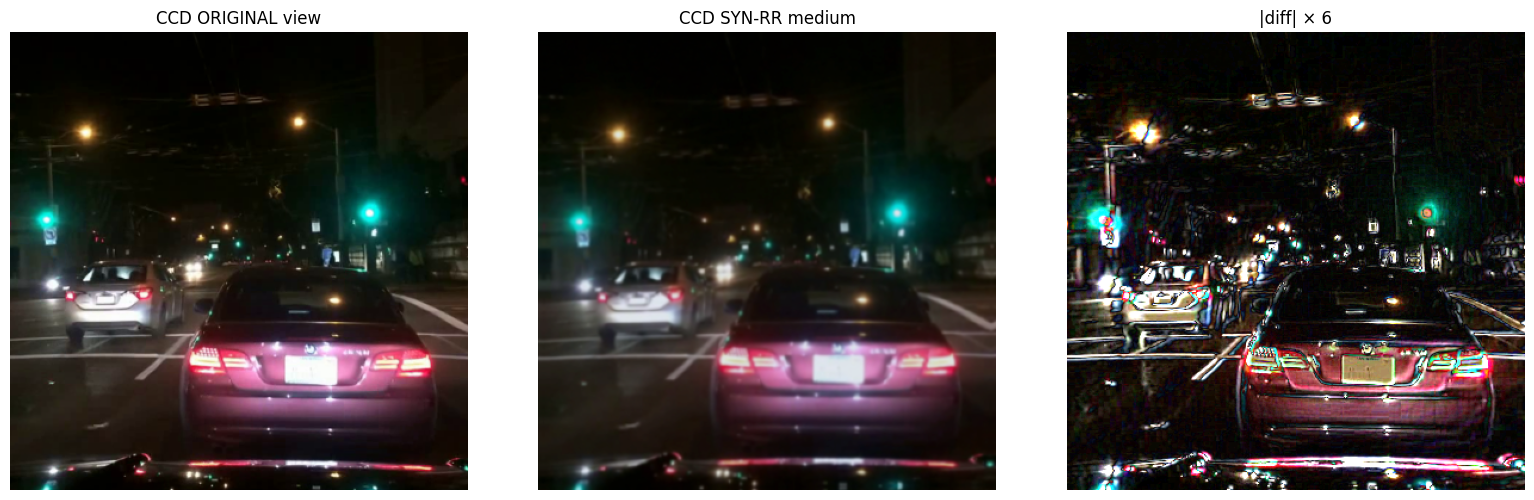

In [7]:
import matplotlib.pyplot as plt

preview_source = ccd_val_sources.iloc[:1].copy()
preview_df, preview_modes = make_ccd_pair_manifest(
    preview_source,
    prefix="preview",
    strength="medium",
    dataset_name="preview_medium",
)
preview_dataset = make_val_dataset(preview_df, preview_modes)

if len(preview_dataset) != 2:
    raise RuntimeError(
        f"Expected exactly 2 preview samples (OR/SYN), got {len(preview_dataset)}. "
        "Keep val_num_clips=1 for this experiment."
    )

preview_or = preview_dataset[0]
preview_syn_1 = preview_dataset[1]
preview_syn_2 = preview_dataset[1]

assert torch.allclose(
    preview_syn_1["pixels"], preview_syn_2["pixels"], atol=1e-5, rtol=0.0
), (
    "Deterministic CCD validation synthetic changed across repeated reads."
)
print("[PASS] deterministic validation synthetic is reproducible")

mean = torch.tensor(preprocessing["mean"], dtype=torch.float32)[:, None, None, None]
std = torch.tensor(preprocessing["std"], dtype=torch.float32)[:, None, None, None]


def first_clip_cthw(sample):
    x = sample["pixels"].detach().cpu().float()
    if x.ndim == 5:      # N,C,T,H,W
        x = x[0]
    elif x.ndim == 4 and x.shape[0] != 3 and x.shape[1] == 3:  # T,C,H,W
        x = x.permute(1, 0, 2, 3)
    if x.ndim != 4 or x.shape[0] != 3:
        raise ValueError(f"Unexpected clip layout: {tuple(x.shape)}")
    return x


def frame_for_display(sample, frame_index=None):
    x = first_clip_cthw(sample)
    t = x.shape[1]
    idx = t // 2 if frame_index is None else int(frame_index)
    rgb = (x * std + mean).clamp(0, 1)[:, idx].permute(1, 2, 0).numpy()
    return rgb

orig_img = frame_for_display(preview_or)
syn_img = frame_for_display(preview_syn_1)
mad = float(np.abs(orig_img - syn_img).mean())
print("preview mean |pixel diff|:", mad)
if mad > 0.15:
    print("WARNING: synthetic preview is very strong. Inspect before training.")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(orig_img); axes[0].set_title("CCD ORIGINAL view")
axes[1].imshow(syn_img); axes[1].set_title("CCD SYN-RR medium")
axes[2].imshow(np.clip(np.abs(orig_img - syn_img) * 6.0, 0, 1)); axes[2].set_title("|diff| × 6")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 7. Evaluation helpers + A7 pre-adaptation diagnostics


In [11]:
def make_ccd_eval_loader(strength: str):
    frame, modes = make_ccd_pair_manifest(
        ccd_val_sources,
        prefix="ccdval",
        strength=strength,
        dataset_name=f"ccd_syn_{strength}",
    )
    dataset = make_val_dataset(frame, modes)
    loader = build_dataloader(
        dataset,
        batch_size=int(video_config["val_batch_size"]),
        shuffle=False,
        num_workers=int(video_config["num_workers"]),
        seed=SEED,
    )
    return frame, loader


def evaluate(model, loader):
    device = next(model.parameters()).device
    evaluator = Stage1Evaluator(
        model,
        ADAPTER,
        device=device,
        amp=AMP,
        aggregation=AGGREGATION,
    )
    started = time.perf_counter()
    result, units = evaluator.evaluate(loader, return_units=True)
    elapsed = time.perf_counter() - started
    return result, units, elapsed


def result_row(name: str, result, elapsed: float, stage: str) -> dict:
    pred = result.predictions.copy()
    correct_prob = np.where(
        pred["label"].astype(str).eq("ORIGINAL"),
        pred["prob_original"].to_numpy(float),
        pred["prob_rerecorded"].to_numpy(float),
    )
    return {
        "stage": stage,
        "eval_set": name,
        "macro_f1_tuned": float(result.macro_f1),
        "macro_f1_at_0.5": float(result.macro_f1_at_default),
        "best_threshold": float(result.threshold),
        "f1_original": float(result.per_class_f1.get("ORIGINAL", float("nan"))),
        "f1_rerecorded": float(result.per_class_f1.get("RERECORDED", float("nan"))),
        "mean_correct_probability": float(np.mean(correct_prob)),
        "p10_correct_probability": float(np.quantile(correct_prob, 0.10)),
        "min_correct_probability": float(np.min(correct_prob)),
        "num_videos": int(result.num_videos),
        "elapsed_seconds": float(elapsed),
    }


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()

baseline_rows = []
baseline_results = {}
if RUN_A7_BASELINE_DIAGNOSTICS:
    print("Evaluating warm-start A7 before CCD adaptation...")
    result, _, elapsed = evaluate(model, dlc_val_loader)
    baseline_results["dlc"] = result
    baseline_rows.append(result_row("dlc", result, elapsed, "A7_before"))
    save_predictions(result.predictions, RUN_DIR / "baseline_a7_dlc_val_predictions.csv")

    for strength in DIAGNOSTIC_STRENGTHS:
        _, loader = make_ccd_eval_loader(strength)
        result, _, elapsed = evaluate(model, loader)
        baseline_results[strength] = result
        baseline_rows.append(result_row(f"ccd_{strength}", result, elapsed, "A7_before"))
        save_predictions(result.predictions, RUN_DIR / f"baseline_a7_ccd_{strength}_predictions.csv")

    baseline_df = pd.DataFrame(baseline_rows)
    display(baseline_df)
    baseline_df.to_csv(RUN_DIR / "baseline_a7_diagnostics.csv", index=False)

    if all(float(baseline_results[s].macro_f1_at_default) >= 0.999999 for s in DIAGNOSTIC_STRENGTHS):
        print(
            "WARNING: A7 already gets perfect @0.5 F1 on every synthetic severity. "
            "The current RecaptureSimV1 may be too easy for model-selection purposes. "
            "Do not treat synthetic-val saturation as evidence of target-domain gain."
        )


Evaluating warm-start A7 before CCD adaptation...


,stage,eval_set,macro_f1_tuned,macro_f1_at_0.5,best_threshold,f1_original,f1_rerecorded,mean_correct_probability,p10_correct_probability,min_correct_probability,num_videos,elapsed_seconds
0,A7_before,dlc,1.000000,0.990180,0.372150,1.000000,1.00000,0.989265,0.998452,0.373576,104,99.017966
1,A7_before,ccd_weak,0.874783,0.858323,0.380061,0.869565,0.88000,0.815204,0.380948,0.008951,120,31.744165
2,A7_before,ccd_medium,0.958307,0.924576,0.836757,0.957265,0.95935,0.886365,0.648953,0.008951,120,34.240718
3,A7_before,ccd_strong,0.950000,0.924576,0.881463,0.950000,0.95000,0.886863,0.648218,0.008951,120,35.421748


## 8. W&B + conservative warm-start training


In [8]:
WANDB_ENABLED = True
WANDB_PROJECT = "blackbox-stage1"
WANDB_ENTITY = os.getenv("WANDB_ENTITY") or None
WANDB_MODE = os.getenv("WANDB_MODE") or None

if WANDB_ENABLED:
    import wandb
    if IN_COLAB:
        key = WANDB_KEY_PATH.read_text(encoding="utf-8").strip()
        if not key:
            raise ValueError(f"W&B key file is empty: {WANDB_KEY_PATH}")
        wandb.login(key=key, relogin=False)
    else:
        wandb.login()

finish_wandb()
wandb_run = init_wandb(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name=f"{MODEL_NAME}__{RUN_VARIANT}__seed{SEED}__{GIT_COMMIT}",
    group=RUN_VARIANT,
    tags=["stage1", "vjepa", "ccd", "synthetic-rerecord", "on-the-fly"],
    config={
        "git_commit": GIT_COMMIT,
        "a7_public_anchor": A7_PUBLIC_ANCHOR,
        "a7_checkpoint": str(A7_BEST),
        "run_variant": RUN_VARIANT,
        "ccd_train_sources": int(CCD_TRAIN_SOURCES),
        "ccd_val_sources": int(CCD_VAL_SOURCES),
        "selection_syn_strength": SELECTION_SYN_STRENGTH,
        "force_head_only": FORCE_HEAD_ONLY,
        "epochs_override": EPOCHS_OVERRIDE,
        "lr_scale_from_a7": LR_SCALE_FROM_A7,
        "recapture_sim": sim_config.to_dict(),
        "base_model_config": CONFIG.get("model", {}),
        "base_train_config": CONFIG.get("train", {}),
        "base_data_config": CONFIG.get("data", {}),
    },
    directory=RUN_DIR / "wandb",
    mode=WANDB_MODE,
)
print("W&B run:", wandb_run.name)
print("W&B url :", wandb_run.url)


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sangchun1 (sangchun1-chung-ang-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


W&B run: vjepa2_1_b__dlc_ccd_synrr_200__seed42__27cc1fb
W&B url : https://wandb.ai/sangchun1-chung-ang-university/blackbox-stage1/runs/i5ry9zpq


In [9]:
base_train_config = CONFIG["train"]
base_lr = float(base_train_config["learning_rate"])
base_head_lr = (
    float(base_train_config["head_learning_rate"])
    if base_train_config.get("head_learning_rate") is not None
    else base_lr
)

adapt_lr = base_lr * LR_SCALE_FROM_A7
adapt_head_lr = base_head_lr * LR_SCALE_FROM_A7

trainer_config = TrainConfig(
    epochs=int(EPOCHS_OVERRIDE),
    learning_rate=float(adapt_lr),
    head_learning_rate=float(adapt_head_lr),
    weight_decay=float(base_train_config["weight_decay"]),
    warmup_ratio=float(base_train_config["warmup_ratio"]),
    grad_accum_steps=int(base_train_config["grad_accum_steps"]),
    max_grad_norm=float(base_train_config["max_grad_norm"]),
    amp=bool(base_train_config["amp"]),
    label_smoothing=float(base_train_config.get("label_smoothing", 0.0)),
    early_stopping_patience=int(EARLY_STOPPING_PATIENCE),
    eval_every=int(base_train_config["eval_every"]),
    seed=SEED,
    output_dir=RUN_DIR,
    model_name=MODEL_NAME,
    wandb_enabled=WANDB_ENABLED,
)

trainer = Stage1Trainer(
    model,
    trainer_config,
    adapter=ADAPTER,
    aggregation=AGGREGATION,
    model_config={
        "name": MODEL_NAME,
        "params": params,
        "experiment": "A7 warm-start + on-the-fly CCD SYN-RR",
    },
)

print("device       :", trainer.device)
print("amp          :", trainer.amp)
print("learning rate:", adapt_lr)
print("head lr      :", adapt_head_lr)
print("train videos :", len(train_df))
print("select val   :", len(selection_val_df))

RESUME_PATH = RUN_DIR / "latest.pt"

if not RESUME_PATH.is_file():
    raise FileNotFoundError(f"Resume checkpoint not found: {RESUME_PATH}")

print("Resuming training from:", RESUME_PATH)

outcome = trainer.fit(
    train_loader,
    selection_val_loader,
    resume_from=RESUME_PATH,
)

print(
    f"best epoch {outcome.best_epoch}: selection-val Macro-F1 "
    f"{outcome.best_macro_f1:.6f} at threshold {outcome.best_threshold:.6f}"
)

device       : cuda
amp          : True
learning rate: 1.25e-05
head lr      : 0.00025
train videos : 883
select val   : 224
Resuming training from: /content/drive/MyDrive/Blackbox-Detection/outputs/stage1/dlc_ccd_synrr_200/vjepa2_1_b/latest.pt
[2026-09-18 08:09:10] INFO | blackbox_detection.stage1.vjepa2_1_b | Resumed from /content/drive/MyDrive/Blackbox-Detection/outputs/stage1/dlc_ccd_synrr_200/vjepa2_1_b/latest.pt at epoch 10 (best epoch 9, F1 0.9730, threshold 0.836).


Train 10/10:   0%|          | 0/883 [00:00<?, ?it/s]

[2026-09-18 08:24:56] INFO | blackbox_detection.stage1.vjepa2_1_b | Epoch 10 | loss 0.0788 | val Macro-F1 0.9730 @ thr 0.733 (0.5: 0.9595)
[2026-09-18 08:24:56] INFO | blackbox_detection.stage1.vjepa2_1_b | Best epoch 9 with validation Macro-F1 0.9730 at threshold 0.836.
best epoch 9: selection-val Macro-F1 0.973040 at threshold 0.836498


## 9. Final guarded evaluation: DLC must not regress


In [12]:
load_checkpoint(
    RUN_DIR / "best.pt",
    model=model,
    map_location="cpu",
    restore_rng_state=False,
)
model = model.to(device).eval()

final_rows = []
final_results = {}

result, _, elapsed = evaluate(model, dlc_val_loader)
final_results["dlc"] = result
final_rows.append(result_row("dlc", result, elapsed, "06_after"))
save_predictions(result.predictions, RUN_DIR / "val_predictions.csv")

for strength in DIAGNOSTIC_STRENGTHS:
    _, loader = make_ccd_eval_loader(strength)
    result, _, elapsed = evaluate(model, loader)
    final_results[strength] = result
    final_rows.append(result_row(f"ccd_{strength}", result, elapsed, "06_after"))
    save_predictions(result.predictions, RUN_DIR / f"ccd_{strength}_val_predictions.csv")

final_df = pd.DataFrame(final_rows)
if baseline_rows:
    comparison_df = pd.concat([pd.DataFrame(baseline_rows), final_df], ignore_index=True)
else:
    comparison_df = final_df.copy()

display(comparison_df)
comparison_df.to_csv(RUN_DIR / "diagnostic_comparison.csv", index=False)
outcome.history.to_csv(RUN_DIR / "history.csv", index=False)


,stage,eval_set,macro_f1_tuned,macro_f1_at_0.5,best_threshold,f1_original,f1_rerecorded,mean_correct_probability,p10_correct_probability,min_correct_probability,num_videos,elapsed_seconds
0,A7_before,dlc,1.000000,0.990180,0.372150,1.000000,1.00000,0.989265,0.998452,0.373576,104,99.017966
1,A7_before,ccd_weak,0.874783,0.858323,0.380061,0.869565,0.88000,0.815204,0.380948,0.008951,120,31.744165
2,A7_before,ccd_medium,0.958307,0.924576,0.836757,0.957265,0.95935,0.886365,0.648953,0.008951,120,34.240718
3,A7_before,ccd_strong,0.950000,0.924576,0.881463,0.950000,0.95000,0.886863,0.648218,0.008951,120,35.421748
4,06_after,dlc,1.000000,0.990180,0.372150,1.000000,1.00000,0.989265,0.998452,0.373576,104,97.743498
5,06_after,ccd_weak,0.874783,0.858323,0.380061,0.869565,0.88000,0.815204,0.380948,0.008951,120,32.784317
6,06_after,ccd_medium,0.958307,0.924576,0.836757,0.957265,0.95935,0.886365,0.648953,0.008951,120,32.981469
7,06_after,ccd_strong,0.950000,0.924576,0.881463,0.950000,0.95000,0.886863,0.648218,0.008951,120,34.112719


In [13]:
# Conservative acceptance guard. Synthetic validation is diagnostic; DLC retention is mandatory.
final_dlc = float(final_results["dlc"].macro_f1_at_default)

if baseline_results:
    baseline_dlc = float(baseline_results["dlc"].macro_f1_at_default)
    no_dlc_regression = final_dlc + 1e-12 >= baseline_dlc
    synthetic_non_regression = all(
        float(final_results[s].macro_f1_at_default) + 1e-12
        >= float(baseline_results[s].macro_f1_at_default)
        for s in DIAGNOSTIC_STRENGTHS
    )
else:
    baseline_dlc = None
    no_dlc_regression = final_dlc >= 0.999999
    synthetic_non_regression = True

summary = {
    "model_name": MODEL_NAME,
    "run_variant": RUN_VARIANT,
    "warm_started_from": str(A7_BEST),
    "a7_public_anchor": A7_PUBLIC_ANCHOR,
    "ccd_train_sources": int(CCD_TRAIN_SOURCES),
    "ccd_train_views": int(len(ccd_train_pair_df)),
    "ccd_val_sources": int(CCD_VAL_SOURCES),
    "selection_syn_strength": SELECTION_SYN_STRENGTH,
    "head_only": bool(FORCE_HEAD_ONLY),
    "best_epoch": int(outcome.best_epoch),
    "selection_val_macro_f1": float(outcome.best_macro_f1),
    "selection_val_best_threshold": float(outcome.best_threshold),
    "final_dlc_macro_f1": float(final_results["dlc"].macro_f1),
    "final_dlc_macro_f1_at_0.5": final_dlc,
    "final_dlc_threshold": float(final_results["dlc"].threshold),
    "baseline_dlc_macro_f1_at_0.5": baseline_dlc,
    "guard_no_dlc_regression": bool(no_dlc_regression),
    "guard_synthetic_non_regression": bool(synthetic_non_regression),
    "candidate_status": (
        "KEEP_FOR_FURTHER_EVALUATION"
        if no_dlc_regression and synthetic_non_regression
        else "REJECT_OR_RETUNE"
    ),
    "important_note": (
        "Synthetic CCD validation is not a substitute for DACON target validation. "
        "Do not spend a submission solely because synthetic-val improved."
    ),
}

(RUN_DIR / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(json.dumps(summary, indent=2))

if WANDB_ENABLED and wandb_run is not None:
    for key, value in summary.items():
        if isinstance(value, (str, int, float, bool)) or value is None:
            wandb_run.summary[key] = value
    try:
        for filename in (
            "summary.json",
            "diagnostic_comparison.csv",
            "history.csv",
            "val_predictions.csv",
            "recapture_sim_config.json",
        ):
            path = RUN_DIR / filename
            if path.is_file():
                wandb_run.save(str(path), base_path=str(RUN_DIR))
    except Exception as exc:
        print("W&B file upload warning:", exc)

finish_wandb()
print("W&B run finished.")
print("saved to:", RUN_DIR)


wandb: WARNING Copied 1 file (cross-volume or links unavailable). Downgrading policy to 'now' for those files because live updates won't propagate from the originals. Re-run wandb.save to resync, or place your run directory on the same drive to enable hardlinks.
wandb: WARNING Copied 1 file (cross-volume or links unavailable). Downgrading policy to 'now' for those files because live updates won't propagate from the originals. Re-run wandb.save to resync, or place your run directory on the same drive to enable hardlinks.
wandb: WARNING Copied 1 file (cross-volume or links unavailable). Downgrading policy to 'now' for those files because live updates won't propagate from the originals. Re-run wandb.save to resync, or place your run directory on the same drive to enable hardlinks.
wandb: WARNING Copied 1 file (cross-volume or links unavailable). Downgrading policy to 'now' for those files because live updates won't propagate from the originals. Re-run wandb.save to resync, or place your r

{
  "model_name": "vjepa2_1_b",
  "run_variant": "dlc_ccd_synrr_200",
  "warm_started_from": "/content/drive/MyDrive/Blackbox-Detection/outputs/stage1/dlc/vjepa2_1_b/best.pt",
  "a7_public_anchor": 0.9549731183,
  "ccd_train_sources": 200,
  "ccd_train_views": 400,
  "ccd_val_sources": 60,
  "selection_syn_strength": "medium",
  "head_only": true,
  "best_epoch": 9,
  "selection_val_macro_f1": 0.9730401989890074,
  "selection_val_best_threshold": 0.8364980816841125,
  "final_dlc_macro_f1": 1.0,
  "final_dlc_macro_f1_at_0.5": 0.9901803417996412,
  "final_dlc_threshold": 0.372149720788002,
  "baseline_dlc_macro_f1_at_0.5": 0.9901803417996412,
  "guard_no_dlc_regression": true,
  "guard_synthetic_non_regression": true,
  "candidate_status": "KEEP_FOR_FURTHER_EVALUATION",
  "important_note": "Synthetic CCD validation is not a substitute for DACON target validation. Do not spend a submission solely because synthetic-val improved."
}


wandb: WARNING Copied 1 file (cross-volume or links unavailable). Downgrading policy to 'now' for those files because live updates won't propagate from the originals. Re-run wandb.save to resync, or place your run directory on the same drive to enable hardlinks.


train/loss,▁
val/f1_ORIGINAL,▁
val/f1_RERECORDED,▁
val/macro_f1,▁
val/macro_f1@0.5,▁
val/macro_f1_ccd_syn_medium,▁
val/macro_f1_dlc2021,▁
val/num_invalid_videos,▁
val/threshold,▁
a7_public_anchor,0.95497
baseline_dlc_macro_f1_at_0.5,0.99018


W&B run finished.
saved to: /content/drive/MyDrive/Blackbox-Detection/outputs/stage1/dlc_ccd_synrr_200/vjepa2_1_b


## 10. 결과 해석 기준

첫 06은 **제출용 모델을 자동 선택하는 notebook이 아니다.** 다음 기준으로 본다.

1. `final_dlc_macro_f1_at_0.5`가 A7의 DLC-val `1.0`에서 내려가면 우선 reject.
2. A7-before가 synthetic weak/medium/strong에서 이미 전부 1.0이면 simulator가 모델 선택용으로 너무 쉬울 수 있다. 이 경우 synthetic 강도를 무작정 키우기보다 **실제 screen-camera physics 다양성**을 늘리는 쪽을 우선한다.
3. synthetic holdout은 CCD-val source를 사용하므로 train content leakage는 없지만, 여전히 우리가 만든 augmentation family 안의 평가다.
4. 06이 안정적이면 다음 실험은 예정대로 **V-JEPA + LCDF residual/gated fusion**이다.
5. DACON 제출은 `summary.json`, confidence 변화, runtime을 본 뒤 별도 inference를 만들어 smoke test한 후 결정한다.
